<a href="https://colab.research.google.com/github/Rakshitanaik-27/EliteTech-DataScience/blob/main/Task4_Optimization_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OPTIMIZATION STATUS: Optimal
Optimal Units of Product A: 20
Optimal Units of Product B: 20
Maximum Total Profit: $1,800.00


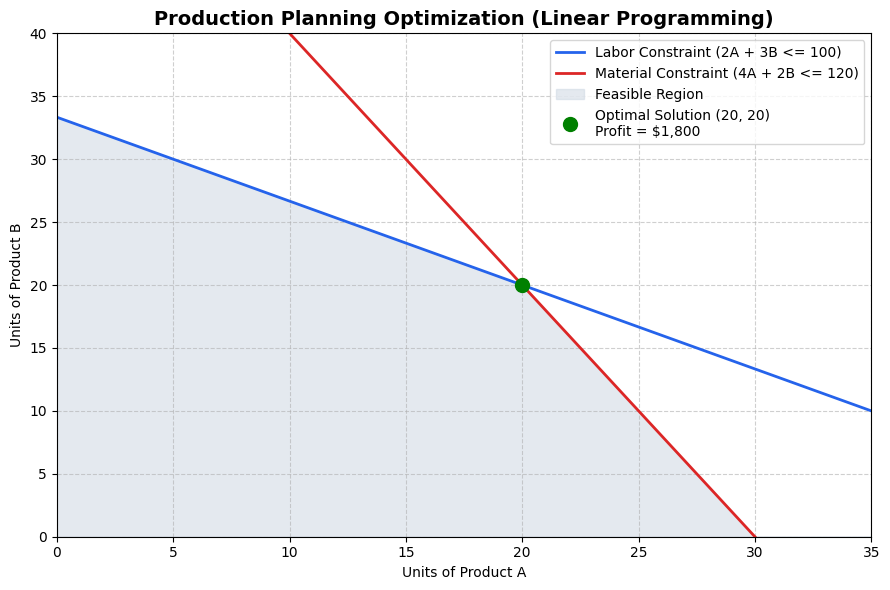

In [4]:
# Install PuLP directly in Colab
!pip install pulp -q

import pulp
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE LINEAR PROGRAMMING PROBLEM
prob = pulp.LpProblem("Production_Optimization", pulp.LpMaximize)

# Decision Variables
x1 = pulp.LpVariable("Product_A_Units", lowBound=0, cat='Integer')
x2 = pulp.LpVariable("Product_B_Units", lowBound=0, cat='Integer')

# Objective Function: Profit = $40 per Product A + $50 per Product B
prob += 40 * x1 + 50 * x2, "Total_Profit"

# Resource Constraints
prob += 2 * x1 + 3 * x2 <= 100, "Labor_Hours_Limit"
prob += 4 * x1 + 2 * x2 <= 120, "Raw_Material_Limit"

# 2. SOLVE PROBLEM
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Extract Results
opt_A = int(pulp.value(x1))
opt_B = int(pulp.value(x2))
max_profit = pulp.value(prob.objective)

print("=" * 50)
print(f"OPTIMIZATION STATUS: {pulp.LpStatus[prob.status]}")
print("=" * 50)
print(f"Optimal Units of Product A: {opt_A}")
print(f"Optimal Units of Product B: {opt_B}")
print(f"Maximum Total Profit: ${max_profit:,.2f}")
print("=" * 50)

# 3. VISUALIZE FEASIBLE REGION AND OPTIMAL POINT
x_vals = np.linspace(0, 40, 400)
y_labor = (100 - 2 * x_vals) / 3
y_material = (120 - 4 * x_vals) / 2

plt.figure(figsize=(9, 6))

# Fixed labels without LaTeX parsing errors
plt.plot(x_vals, y_labor, label='Labor Constraint (2A + 3B <= 100)', color='#2563eb', linewidth=2)
plt.plot(x_vals, y_material, label='Material Constraint (4A + 2B <= 120)', color='#dc2626', linewidth=2)

y_feasible = np.minimum(np.maximum(0, y_labor), np.maximum(0, y_material))
plt.fill_between(x_vals, 0, y_feasible, where=(x_vals >= 0), color='#cbd5e1', alpha=0.5, label='Feasible Region')

plt.plot(opt_A, opt_B, 'go', markersize=10, label=f'Optimal Solution ({opt_A}, {opt_B})\nProfit = ${max_profit:,.0f}')

plt.xlim(0, 35)
plt.ylim(0, 40)
plt.xlabel('Units of Product A')
plt.ylabel('Units of Product B')
plt.title('Production Planning Optimization (Linear Programming)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()